# 08 logistic regression — binary classification

In [1]:
from pathlib import Path

# Works whether the notebook is run from the project root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              f1_score, roc_auc_score, roc_curve, auc,
                              precision_recall_curve)

import shap
import lime
import lime.lime_tabular

## load raw dataset + rebuild features

In [3]:
df = pd.read_excel(DATA_DIR / "carbon_footprint_dataset.xlsx")  # original raw source, not the processed CSV
print("raw shape:", df.shape)
df.head()


raw shape: (500, 11)


,household_size,annual_income_usd,electricity_kwh_per_month,natural_gas_therms_per_month,fuel_liters_per_month,food_spend_usd_per_month,meat_kg_per_month,waste_kg_per_month,public_transport_km_per_month,car_km_per_month,estimated_co2_kg_per_month
0,4,29397,1143.4,35.6,145.2,1147.93,7.06,57.1,42.1,368.9,1368.87
1,5,146800,542.0,145.7,163.6,1047.98,17.88,21.4,237.2,404.6,1996.21
2,3,134180,434.3,27.1,42.7,1299.29,18.93,49.6,109.1,773.4,1181.96
3,5,81234,826.2,128.2,101.2,1100.24,17.85,24.8,94.1,102.3,1812.36
4,5,54954,579.2,73.8,168.1,758.91,8.39,54.6,496.4,795.6,1542.72


## feature engineering

In [4]:
# per-capita normalisation
df["energy_per_person"] = df["electricity_kwh_per_month"] / df["household_size"]
df["food_per_person"]   = df["food_spend_usd_per_month"]  / df["household_size"]
df["waste_per_person"]  = df["waste_kg_per_month"]        / df["household_size"]
df["meat_per_person"]   = df["meat_kg_per_month"]         / df["household_size"]

# car-to-public ratio (+1 smoothing)
df["transport_ratio"] = df["car_km_per_month"] / (df["public_transport_km_per_month"] + 1)  # +1 Laplace smoothing prevents division by zero

# income on log scale
df["log_income"] = np.log1p(df["annual_income_usd"])

df[["energy_per_person", "food_per_person", "waste_per_person",
    "meat_per_person", "transport_ratio", "log_income"]].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
energy_per_person,500.0,312.270,256.728,32.440,142.675,223.052,387.742,1197.000
food_per_person,500.0,392.485,322.099,42.038,181.794,287.224,481.629,1492.000
waste_per_person,500.0,19.518,17.278,1.000,8.122,14.083,24.162,79.900
meat_per_person,500.0,4.543,4.104,0.000,1.675,3.475,5.852,19.610
transport_ratio,500.0,12.938,72.704,0.001,1.563,3.350,6.711,1434.900
log_income,500.0,11.153,0.610,9.624,10.713,11.300,11.677,11.918


## build binary target

In [5]:
median_co2 = df["estimated_co2_kg_per_month"].median()  # split point = median monthly CO2
df["carbon_binary"] = (df["estimated_co2_kg_per_month"] > median_co2).astype(int)  # 1 = high emitter, 0 = low emitter

print("median CO2 :", round(median_co2, 2))
print(df["carbon_binary"].value_counts().rename({0: "low (0)", 1: "high (1)"}))

median CO2 : 1469.1
carbon_binary
low (0)     250
high (1)    250
Name: count, dtype: int64


## feature selection

In [6]:
feature_cols = [  # raw drivers + lightweight engineered ratios (no leakage-prone aggregates)
    "electricity_kwh_per_month", "natural_gas_therms_per_month",
    "fuel_liters_per_month", "car_km_per_month",
    "public_transport_km_per_month", "meat_kg_per_month",
    "energy_per_person", "transport_ratio",
    "food_per_person", "log_income"
]

X = df[feature_cols]
y = df["carbon_binary"]  # binary label: 0 = low, 1 = high

## train test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # preserves 50/50 balance in both splits
)
print("train:", X_train.shape, "  test:", X_test.shape)

train: (400, 10)   test: (100, 10)


## pipeline + hyperparameter tuning

In [8]:
pipeline = Pipeline([  # scaler + model chained -> no data leakage
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

param_grid = {"model__C": [0.01, 0.1, 1, 10, 100]}  # C: inverse regularisation strength
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # stratified folds maintain class ratio

search = GridSearchCV(pipeline, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)  # exhaustive C sweep
search.fit(X_train, y_train)

best_model = search.best_estimator_  # pipeline with optimal C
print("best C:", search.best_params_)

best C: {'model__C': 10}


## regularisation path (C selection)

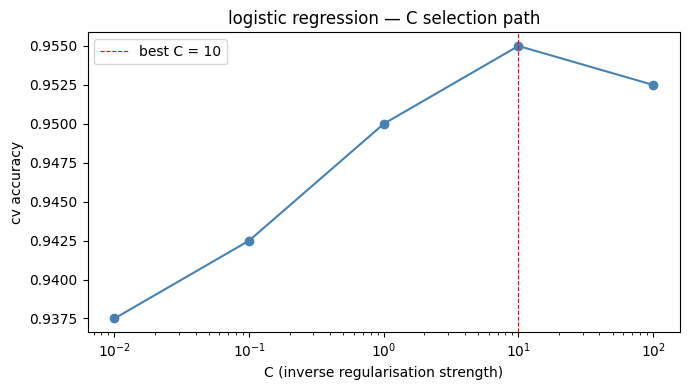

In [9]:
C_grid = param_grid["model__C"]
mean_scores = search.cv_results_["mean_test_score"]  # CV accuracy per C value

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(C_grid, mean_scores, "o-", color="steelblue")
ax.axvline(search.best_params_["model__C"], color="red", linestyle="--",
           linewidth=0.8, label=f"best C = {search.best_params_['model__C']}")  # selected C
ax.set_xlabel("C (inverse regularisation strength)")
ax.set_ylabel("cv accuracy")
ax.set_title("logistic regression — C selection path")
ax.legend()
plt.tight_layout()
plt.show()

## cross-validation scores

In [10]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="accuracy")  # CV on training set only
print(f"cv accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

cv accuracy: 0.9550 +/- 0.0127


## overfitting check

In [11]:
best_model.fit(X_train, y_train)
train_acc = accuracy_score(y_train, best_model.predict(X_train))  # in-sample accuracy
test_acc  = accuracy_score(y_test,  best_model.predict(X_test))   # out-of-sample accuracy

print(f"train accuracy: {train_acc:.4f}")
print(f"test  accuracy: {test_acc:.4f}")
print(f"train-test gap: {train_acc - test_acc:+.4f}")  # ~0, no overfitting

train accuracy: 0.9675
test  accuracy: 0.9800
train-test gap: -0.0125


Test **0.98**, higher than the 3-class model (0.95) — expected, since merging into 2 classes drops the hard middle group. Not a better model, just an easier task.

## final evaluation

In [12]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]  # P(class = high) for ROC / PR curves

print("accuracy   :", accuracy_score(y_test, y_pred))
print("weighted f1:", f1_score(y_test, y_pred, average="weighted"))
print()
print(classification_report(y_test, y_pred, target_names=["low (0)", "high (1)"]))  # per-class precision / recall / F1

accuracy   : 0.98
weighted f1: 0.9799919967987194

              precision    recall  f1-score   support

     low (0)       0.96      1.00      0.98        50
    high (1)       1.00      0.96      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



## confusion matrix

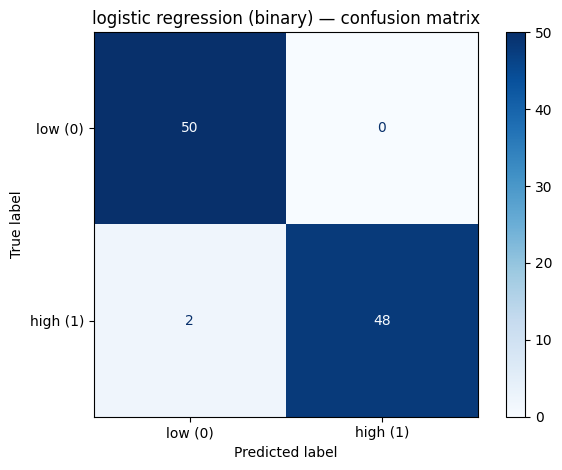

In [13]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["low (0)", "high (1)"]).plot(cmap="Blues")
plt.title("logistic regression (binary) — confusion matrix")
plt.tight_layout()
plt.show()

Very few errors — the 2-class task is much easier than 3-class.

## roc curve

ROC-AUC: 0.9964


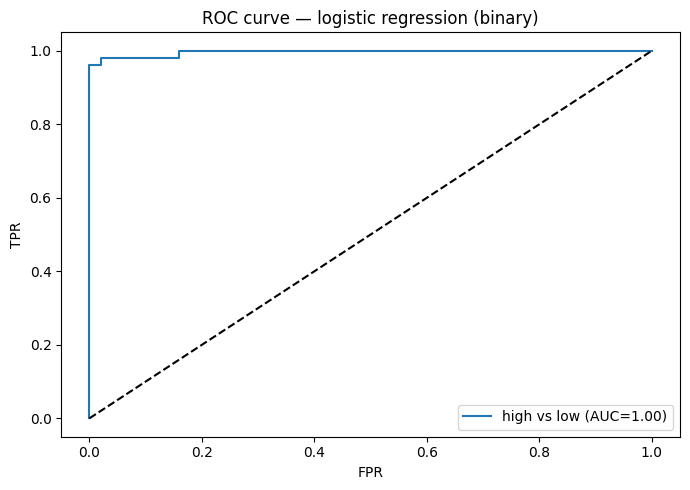

In [14]:
roc_auc = roc_auc_score(y_test, y_prob)  # single-curve AUC for binary target
print("ROC-AUC:", round(roc_auc, 4))

fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, label=f"high vs low (AUC={auc(fpr, tpr):.2f})")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC curve — logistic regression (binary)")
ax.legend()
plt.tight_layout()
plt.show()

AUC ~0.99, near-perfect separation.

## precision-recall curve

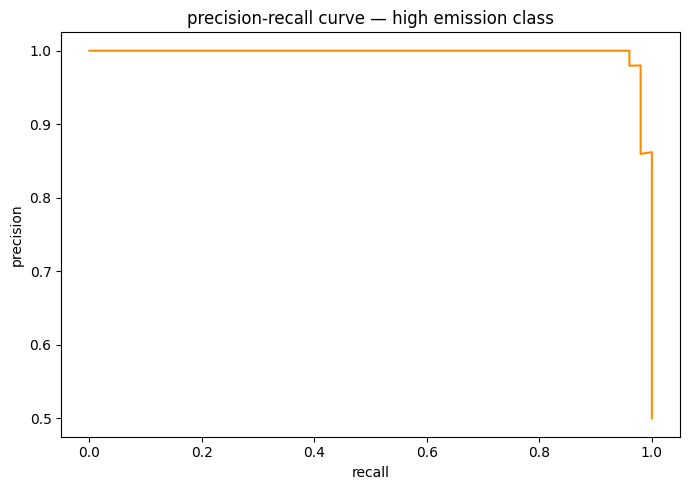

In [15]:
prec, rec, _ = precision_recall_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, color="darkorange")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("precision-recall curve — high emission class")
plt.tight_layout()
plt.show()

## coefficient interpretation

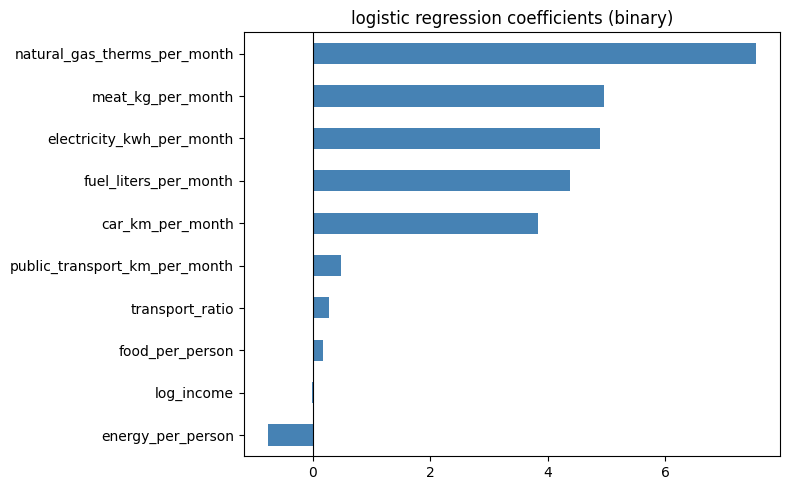

,coefficient (-> high)
energy_per_person,-0.760
log_income,-0.008
food_per_person,0.181
transport_ratio,0.279
public_transport_km_per_month,0.477
car_km_per_month,3.826
fuel_liters_per_month,4.373
electricity_kwh_per_month,4.892
meat_kg_per_month,4.946
natural_gas_therms_per_month,7.534


In [16]:
coef_df = pd.DataFrame(  # single coefficient vector for the binary model
    best_model.named_steps["model"].coef_.T,
    index=feature_cols,
    columns=["coefficient (-> high)"]
).sort_values("coefficient (-> high)")

fig, ax = plt.subplots(figsize=(8, 5))
coef_df["coefficient (-> high)"].plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("logistic regression coefficients (binary)")
plt.tight_layout()
plt.show()

coef_df.round(3)

## shap — linear explainer (global)

c:\Users\YJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


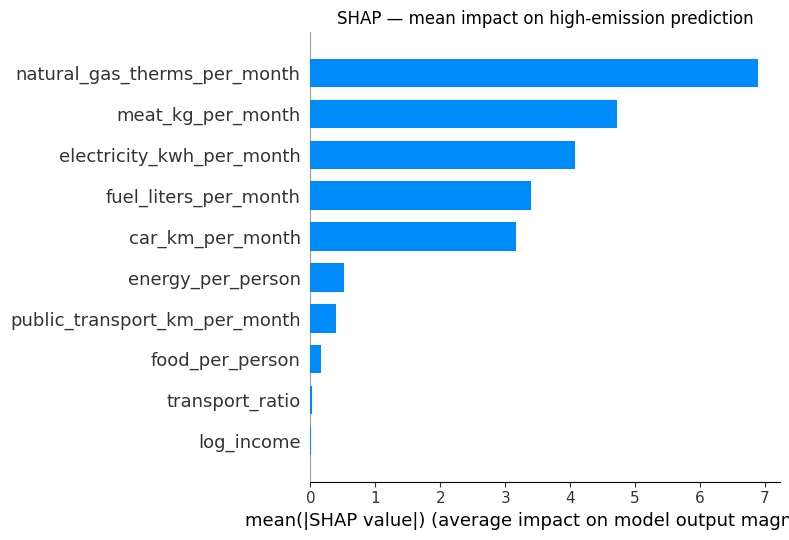

In [17]:
scaler = best_model.named_steps["scaler"]
lr     = best_model.named_steps["model"]

X_train_scaled = scaler.transform(X_train)  # manual scaling outside pipeline for SHAP
X_test_scaled  = scaler.transform(X_test)

explainer_shap = shap.LinearExplainer(lr, X_train_scaled, feature_perturbation="interventional")  # interventional: marginalises feature correlations
shap_values    = explainer_shap.shap_values(X_test_scaled)  # binary -> single (n_samples, n_features) array

shap.summary_plot(
    shap_values, X_test_scaled,
    feature_names=feature_cols,
    plot_type="bar", max_display=len(feature_cols), show=False
)
plt.title("SHAP — mean impact on high-emission prediction")
plt.tight_layout()
plt.show()

## shap — beeswarm

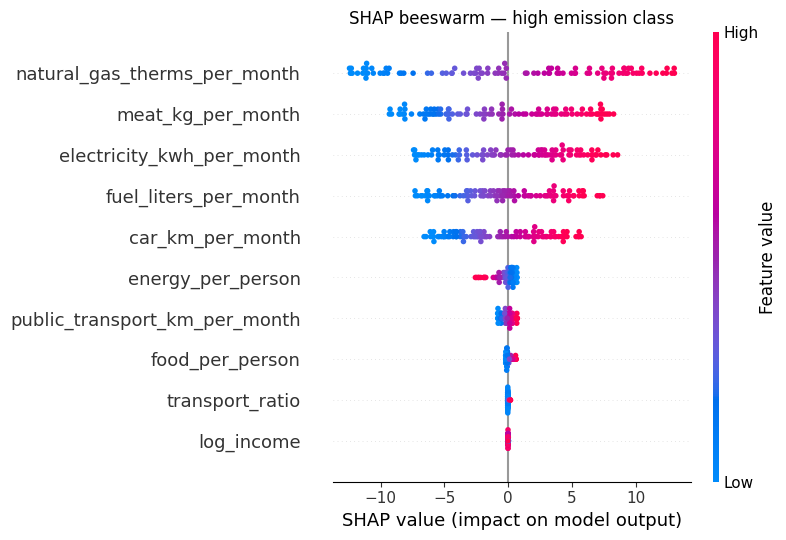

In [18]:
shap.summary_plot(
    shap_values, X_test_scaled,
    feature_names=feature_cols,
    max_display=len(feature_cols), show=False
)
plt.title("SHAP beeswarm — high emission class")
plt.tight_layout()
plt.show()

## shap — waterfall (single prediction)

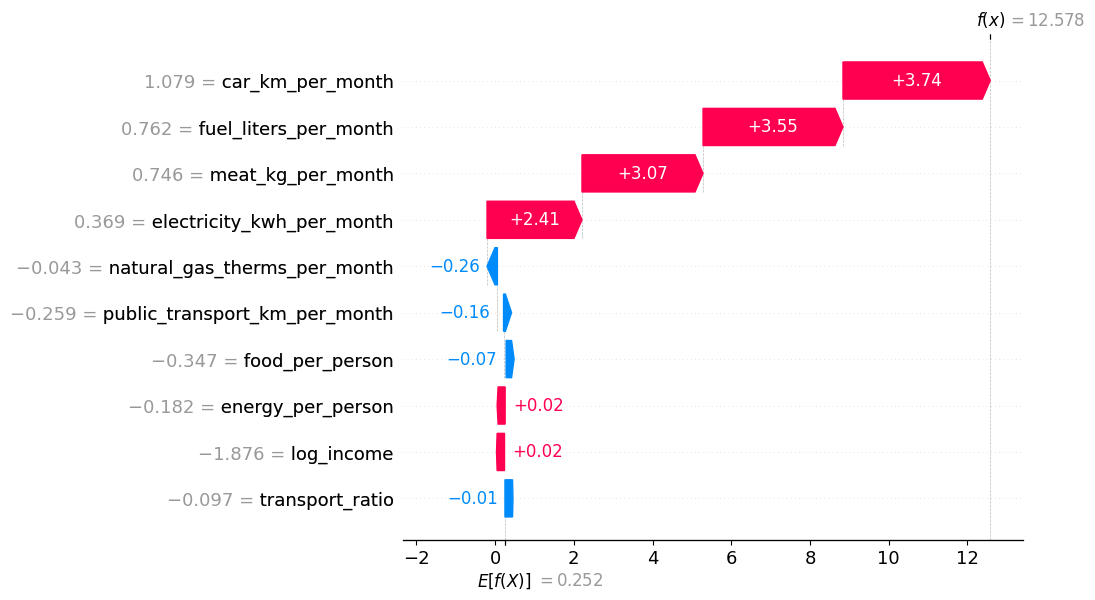

In [19]:
pred_labels = best_model.predict(X_test)
pick = (pred_labels == 1).nonzero()[0][0]  # first predicted "high" sample

base_val = explainer_shap.expected_value
base_val = base_val[0] if hasattr(base_val, "__len__") else base_val  # handle scalar vs array expected_value

shap.waterfall_plot(
    shap.Explanation(
        values       = shap_values[pick],
        base_values  = base_val,
        data         = X_test_scaled[pick],
        feature_names= feature_cols
    )
)

## lime — local instance explanation

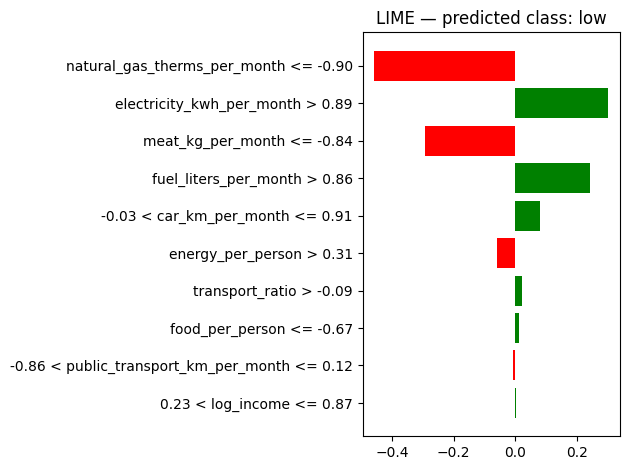

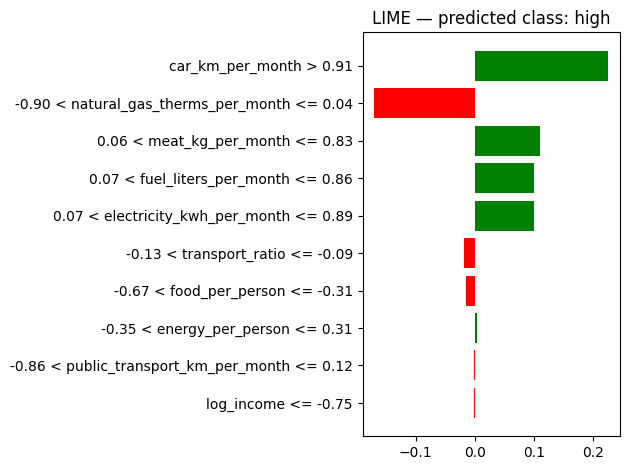

In [20]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=feature_cols,
    class_names=["low", "high"],
    discretize_continuous=True,  # LIME bins continuous features for local linear fit
    random_state=42
)

for cls_idx, cls_name in enumerate(["low", "high"]):
    idx = (pred_labels == cls_idx).nonzero()[0][0]  # first sample predicted as this class
    exp = explainer_lime.explain_instance(  # perturbs one sample; fits local linear model
        X_test_scaled[idx],
        lr.predict_proba,
        num_features=len(feature_cols)
    )
    exp.as_pyplot_figure()
    plt.title(f"LIME — predicted class: {cls_name}")
    plt.tight_layout()
    plt.show()